In [1]:
!git clone https://github.com/DavorSopar/dataset-analysis.git /content/dataset-analysis
import sys
sys.path.insert(0, '/content/dataset-analysis/src')

Cloning into '/content/dataset-analysis'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 35 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 1.41 MiB | 1.17 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

# Make src/ importable whether run from notebooks/ or the repo root.
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "src").is_dir():
    pass
elif (REPO_ROOT.parent / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
from data import load_convt, impute_selfdisclosure, TARGETS

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

In [3]:
# Load and resolve the two missing SelfDisclosure values (speaker-mean; see 01_eda).
df = impute_selfdisclosure(load_convt())
print(f"{len(df):,} turns across {df['conversation_id'].nunique()} conversations")
print("Targets:", TARGETS)

11,166 turns across 487 conversations
Targets: ['Emotion', 'EmotionalPolarity', 'Empathy', 'SelfDisclosure']


In [4]:
groups = df["conversation_id"].to_numpy()

# 70% train, 30% temp
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, temp_idx = next(gss1.split(df, groups=groups))

# split temp 50/50 -> 15% dev, 15% test (still grouped)
temp = df.iloc[temp_idx]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_STATE)
dev_rel, test_rel = next(gss2.split(temp, groups=temp["conversation_id"].to_numpy()))
dev_idx, test_idx = temp_idx[dev_rel], temp_idx[test_rel]

train, dev, test = df.iloc[train_idx], df.iloc[dev_idx], df.iloc[test_idx]

# Guarantee no conversation appears in more than one split.
assert not (set(train.conversation_id) & set(dev.conversation_id))
assert not (set(train.conversation_id) & set(test.conversation_id))
assert not (set(dev.conversation_id) & set(test.conversation_id))

split_tbl = pd.DataFrame({
    "turns": [len(train), len(dev), len(test)],
    "conversations": [train.conversation_id.nunique(),
                      dev.conversation_id.nunique(),
                      test.conversation_id.nunique()],
}, index=["train", "dev", "test"])
split_tbl["turns_%"] = (100 * split_tbl["turns"] / len(df)).round(1)
print(split_tbl)
print("\nNo conversation overlaps across splits. Good.")

       turns  conversations  turns_%
train   7788            340  69.7000
dev     1640             73  14.7000
test    1738             74  15.6000

No conversation overlaps across splits. Good.


In [5]:
def pearson(y_true, y_pred):
    """Pearson r; returns NaN when either side is constant (undefined)."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])

def score_all(y_true, y_pred):
    return {
        "pearson": pearson(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

In [6]:
# Target for this notebook: Empathy only.
TARGET = 'Empathy'
y_train = train[TARGET]
y_dev = dev[TARGET]
y_test = test[TARGET]

# TF-IDF Ridge baseline model

In [7]:
# Final config from Days 8-10 sweeps
BEST_ALPHA = 3.0

# Rebuild vectorizer and transform all three splits
vec = TfidfVectorizer(ngram_range=(1,1), max_features=10000)
X_tr = vec.fit_transform(train["text"])
X_dv = vec.transform(dev["text"])
X_te = vec.transform(test["text"])

y_train = train["Empathy"]
y_dev = dev["Empathy"]
y_test = test["Empathy"]

# Train the final Ridge model
final_ridge = Ridge(alpha=BEST_ALPHA).fit(X_tr, y_train)

# Evaluation helper
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r = pearsonr(y_true, y_pred)[0]
    print(f"{label:35s}  MAE={mae:.4f}  RMSE={rmse:.4f}  Pearson={r:.4f}")
    return {"label": label, "mae": mae, "rmse": rmse, "pearson": r}

# Evaluate on both splits
dev_results = evaluate(y_dev, final_ridge.predict(X_dv), "Final Ridge baseline · dev")
test_results = evaluate(y_test, final_ridge.predict(X_te), "Final Ridge baseline · test")

Final Ridge baseline · dev           MAE=0.5632  RMSE=0.7068  Pearson=0.6425
Final Ridge baseline · test          MAE=0.6060  RMSE=0.7573  Pearson=0.6429


# RoBERTa model

In [8]:
from transformers import AutoTokenizer
from datasets import Dataset

checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

# Convert pandas → HF Dataset, rename Empathy to labels (Trainer expects "labels")
train_ds = Dataset.from_pandas(train[["text", "Empathy"]].rename(columns={"Empathy": "labels"}))
dev_ds   = Dataset.from_pandas(dev[["text", "Empathy"]].rename(columns={"Empathy": "labels"}))
test_ds  = Dataset.from_pandas(test[["text", "Empathy"]].rename(columns={"Empathy": "labels"}))

# Tokenize all splits
train_ds = train_ds.map(tokenize_fn, batched=True)
dev_ds   = dev_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

# Ensure labels are float32 (regression needs floats, not ints)
import torch
train_ds = train_ds.map(lambda x: {"labels": float(x["labels"])})
dev_ds   = dev_ds.map(lambda x: {"labels": float(x["labels"])})
test_ds  = test_ds.map(lambda x: {"labels": float(x["labels"])})

# Sanity check
print(train_ds[0])

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Map:   0%|          | 0/1738 [00:00<?, ? examples/s]

Map:   0%|          | 0/7788 [00:00<?, ? examples/s]

Map:   0%|          | 0/1640 [00:00<?, ? examples/s]

Map:   0%|          | 0/1738 [00:00<?, ? examples/s]

{'text': 'I feel very sad for the people.', 'labels': 3.3333, '__index_level_0__': 22, 'input_ids': [0, 100, 619, 182, 5074, 13, 5, 82, 4, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [9]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Load the model with a regression head
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=1,
    problem_type="regression",
)

# Data collator handles per-batch padding automatically
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Metrics function — same three you've been using
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.squeeze()  # shape (n, 1) → (n,)
    mae = mean_absolute_error(labels, predictions)
    rmse = np.sqrt(mean_squared_error(labels, predictions))
    r = pearsonr(labels, predictions)[0]
    return {"mae": mae, "rmse": rmse, "pearson": r}

# Training configuration
training_args = TrainingArguments(
    output_dir="./roberta_empathy",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="pearson",
    greater_is_better=True,
    logging_steps=100,
    report_to="none",  # disables wandb/tensorboard reporting
)

# Assemble the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Sanity check — this should print without errors
print("Trainer is ready. Do not call trainer.train() yet.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer is ready. Do not call trainer.train() yet.


In [10]:
trainer.train()

Epoch,Training Loss,Validation Loss,Mae,Rmse,Pearson
1,0.489909,0.495538,0.552959,0.703945,0.703914
2,0.384405,0.428069,0.505067,0.654270,0.727266
3,0.282753,0.421431,0.504028,0.649177,0.730758


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1461, training_loss=0.42502160173503606, metrics={'train_runtime': 343.5452, 'train_samples_per_second': 68.009, 'train_steps_per_second': 4.253, 'total_flos': 752256530777424.0, 'train_loss': 0.42502160173503606, 'epoch': 3.0})

In [18]:
# Generate test predictions from both models

# Ridge — direct prediction
X_te = vec.transform(test["text"])   # or however you named your loaded vectorizer
ridge_preds = final_ridge.predict(X_te)           # or however you named the loaded model

# RoBERTa — via trainer.predict
roberta_output = trainer.predict(test_ds)
roberta_preds = roberta_output.predictions.squeeze()   # shape (n, 1) → (n,)

# True labels
y_test = test["Empathy"].values

# Sanity check
print(f"ridge_preds: shape {ridge_preds.shape}, range [{ridge_preds.min():.2f}, {ridge_preds.max():.2f}]")
print(f"roberta_preds: shape {roberta_preds.shape}, range [{roberta_preds.min():.2f}, {roberta_preds.max():.2f}]")
print(f"y_test: shape {y_test.shape}, range [{y_test.min():.2f}, {y_test.max():.2f}]")

ridge_preds: shape (1738,), range [0.63, 4.06]
roberta_preds: shape (1738,), range [0.74, 3.88]
y_test: shape (1738,), range [0.00, 4.67]


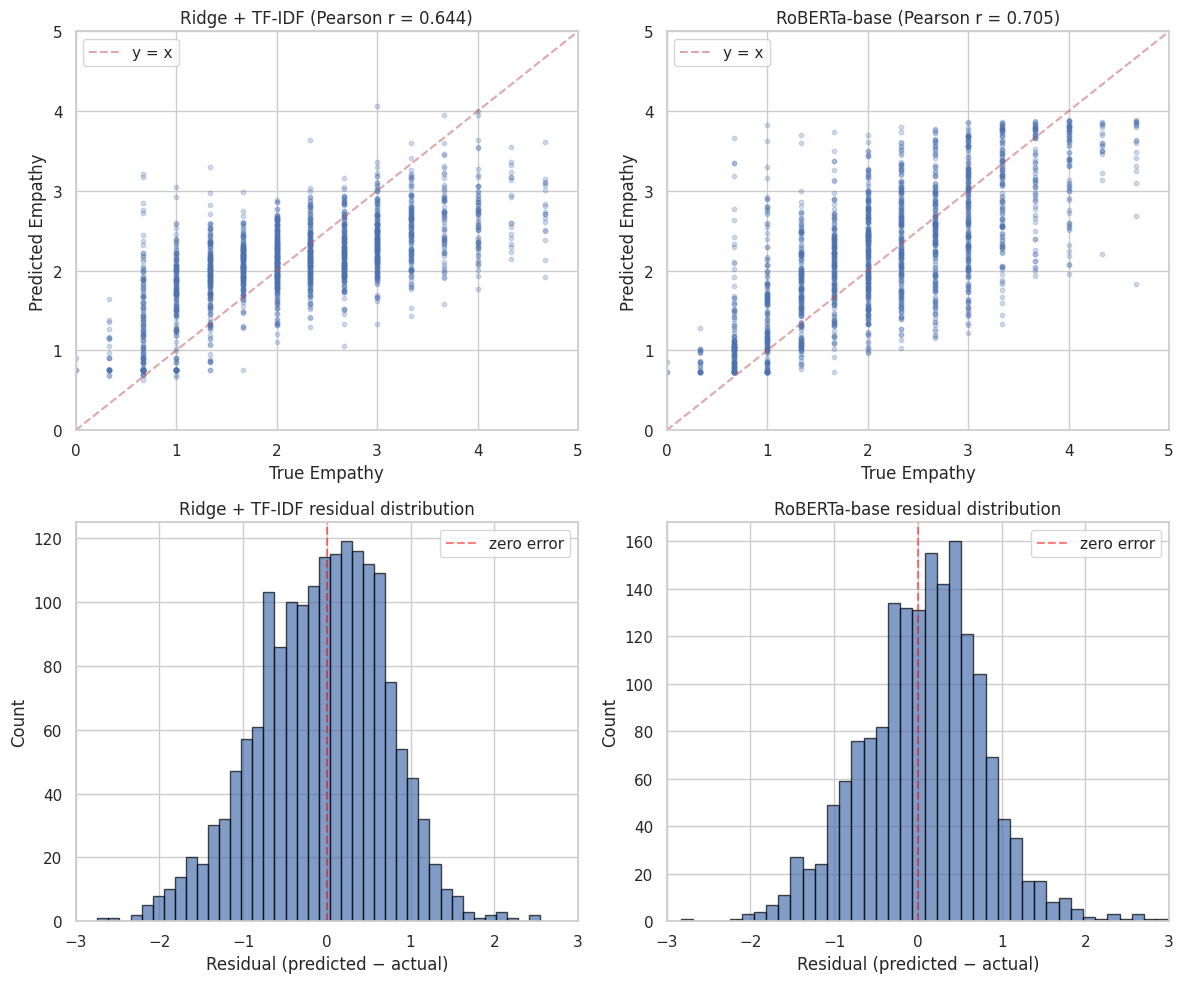

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs('figures', exist_ok=True)
# You should already have:
# - ridge_preds: Ridge's test predictions
# - roberta_preds: RoBERTa's test predictions
# - y_test: true empathy scores

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Top row: predicted vs actual scatter ---
for ax, preds, name, r in [
    (axes[0, 0], ridge_preds, "Ridge + TF-IDF", 0.644),
    (axes[0, 1], roberta_preds, "RoBERTa-base", 0.705),
]:
    ax.scatter(y_test, preds, alpha=0.25, s=10)
    ax.plot([0, 5], [0, 5], 'r--', alpha=0.5, label='y = x')
    ax.set_xlabel('True Empathy')
    ax.set_ylabel('Predicted Empathy')
    ax.set_title(f'{name} (Pearson r = {r})')
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 5)
    ax.legend(loc='upper left')

# --- Bottom row: residual histograms ---
ridge_residuals = ridge_preds - y_test
roberta_residuals = roberta_preds - y_test

for ax, residuals, name in [
    (axes[1, 0], ridge_residuals, "Ridge + TF-IDF"),
    (axes[1, 1], roberta_residuals, "RoBERTa-base"),
]:
    ax.hist(residuals, bins=40, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='zero error')
    ax.set_xlabel('Residual (predicted − actual)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} residual distribution')
    ax.legend()
    ax.set_xlim(-3, 3)

plt.tight_layout()
plt.savefig('figures/predictions_and_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

"Figure X shows predicted vs actual empathy scores for both models on the test set. The vertical banding is an artifact of the annotation process: because empathy labels are averages of three integer annotator ratings, only a small set of discrete true values occurs in practice, and predictions for each true value stack vertically. At each true value, the spread of predictions and the offset from the y=x line reveal model behavior. Both models exhibit compression toward the mean of the training distribution: predictions at low true empathy (≈1) are systematically higher than the true value, and predictions at high true empathy (≈5) are systematically lower. RoBERTa shows tighter vertical bands and less pronounced compression than Ridge, consistent with its higher Pearson correlation."